# 04 — Approach I: cluster-based manual annotation

Requires `config/fov46_annotation.json` to contain the manually selected Leiden resolution and a complete cluster→cell-type mapping. The production script generates top markers, marker-panel plots, UMAP, coordinate spatial maps, filled segmentation maps, and white-outline segmentation maps.

In [1]:
from pathlib import Path
import sys, os

# Notebook lives in PROJECT_ROOT/jupyter/.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "jupyter" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.executable)
assert (PROJECT_ROOT / "scripts").exists(), "Run this notebook from PROJECT_ROOT/jupyter or PROJECT_ROOT."

PROJECT_ROOT: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python: /home/jqu/.conda/envs/spatialdata/bin/python


In [2]:
print((PROJECT_ROOT/"config/fov46_annotation.json").read_text())

{
  "resolution": 0.6,
  "cluster_annotations": {
    "0": "Plasma_cell",
    "1": "Macrophage",
    "2": "Epithelial",
    "3": "Fibroblast",
    "4": "Endothelial",
    "5": "Plasma_cell"
  }
}



In [ ]:
%run ../scripts/04c_approach_i_annotation.py

## Inspect annotations

,leiden,cell_type_scanpy,n
0,0,Plasma_cell,377
1,1,Macrophage,242
2,2,Epithelial,141
3,3,Fibroblast,137
4,4,Endothelial,24
5,5,Plasma_cell,17


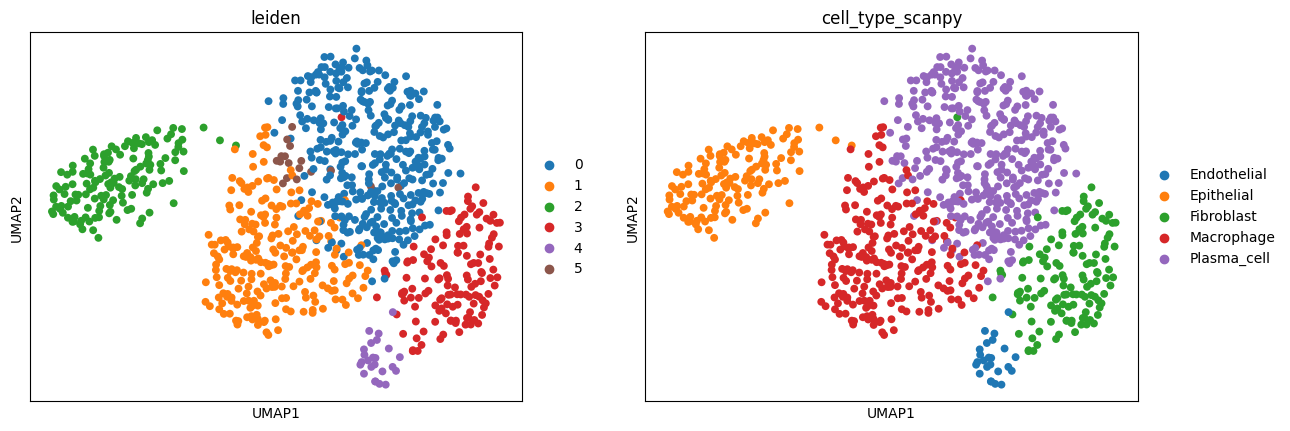

In [3]:
import scanpy as sc, pandas as pd
from IPython.display import display
a=sc.read_h5ad(PROJECT_ROOT/"results/FOV46/GSM9046088_FOV46_approach_i.h5ad")
display(a.obs[["leiden","cell_type_scanpy"]].value_counts().reset_index(name="n"))
sc.pl.umap(a,color=["leiden","cell_type_scanpy"],frameon=True)

## Inspect saved top-marker table

In [4]:
r=a.uns.get("selected_leiden_resolution")
f=PROJECT_ROOT/f"results/FOV46/tables/leiden_top10_markers_r{r:g}.csv"
display(pd.read_csv(f))

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,IGHG1,17.453619,1.673616,3.231004e-68,3.231004e-65,1.000000,0.994652
1,0,IGHG2,16.342540,2.153990,4.916033e-60,1.638678e-57,0.986737,0.926916
2,0,IGKC,16.257982,1.219864,1.960920e-59,4.902300e-57,1.000000,0.998217
3,0,MZB1,11.245230,2.732463,2.444588e-29,2.222353e-27,0.689655,0.331551
4,0,XBP1,8.186818,1.462670,2.682223e-16,1.166184e-14,0.745358,0.575758
5,0,IGHM,6.062130,1.609525,1.343310e-09,2.633941e-08,0.578249,0.415330
6,0,JCHAIN,5.842372,1.835156,5.146265e-09,9.028536e-08,0.427056,0.217469
7,0,LPAR5,5.471440,1.644501,4.463943e-08,6.662602e-07,0.405836,0.199643
8,0,MPO,4.761653,1.573225,1.920134e-06,2.258982e-05,0.344828,0.172906
9,0,IRF4,4.062437,1.489082,4.856311e-05,4.335992e-04,0.297082,0.142602
